# To-dos (13/11/23)

1. Remove fits to log, only use fit_short
2. Investigate the bad fits for the slices 
3. Confirm that the mcmc really does work for the entire fit
4. Plot the curve using [a, b, c, d] and play around with these values
5. Fix d = 0.5, and add "error parameters" for the temperature (eT + f) 
6. Run mcmc for this starting from e = 1, f = 0
7. Just use the entire series as your fit function

In [1]:
import emcee as mc #try markov chain monte carlo

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import data_analysis_script as da
import importlib as im
from scipy.optimize import curve_fit, minimize
import emcee as mc #try markov chain monte carlo

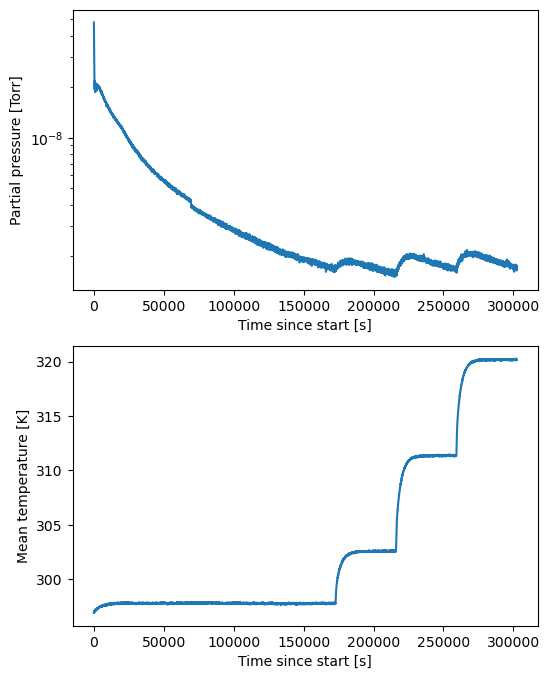

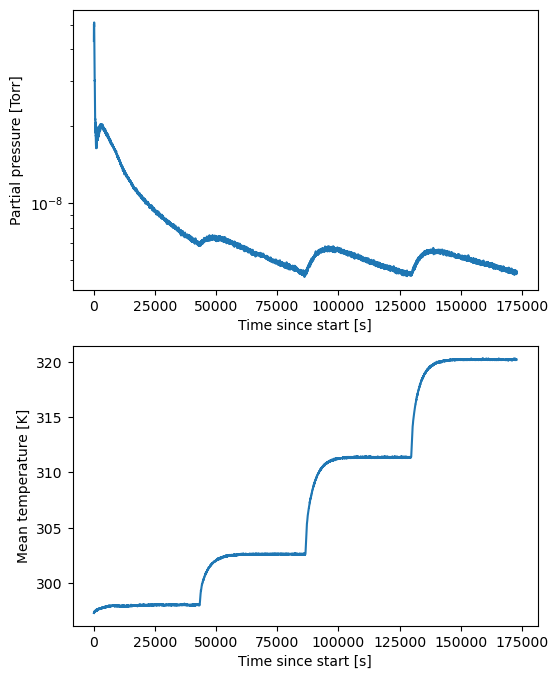

In [9]:
from data_analysis_script import Dataset
run_label = '2024-07-15' ## Change this to look at different runs
d = Dataset(run_label=run_label, gases=['O2'], data_path='20240715/')
d.GetData()
d.PlotSingleGas('O2')


from data_analysis_script import Dataset
run_label = '2024-05-30' ## Change this to look at different runs
o = Dataset(run_label=run_label, gases=['O2'], data_path='20240530/')
o.GetData()
o.PlotSingleGas('O2')



In [10]:
time = np.array(d.data['O2']['Exposure_time'])
temp = np.array(d.data['O2']['Mean_temp']) #['Mean_temp'])
p = np.array(d.data['O2']['Partial_pressure'])



Btime = np.array(o.data['O2']['Exposure_time'])
Btemp = np.array(o.data['O2']['Mean_temp']) #['Mean_temp'])
BPr = np.array(o.data['O2']['Partial_pressure'])

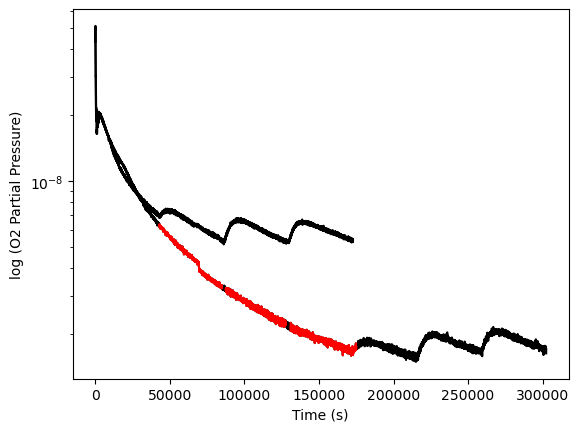

In [14]:
time_slices = [[43000, 85000],
               [87500, 127500],
               [131000, 175000]]

plt.semilogy(time, p, 'k') # Plot the logarithm (base 10) of the partial pressure of O2 (oxygen) against time. 
plt.ylabel('log (O2 Partial Pressure)') 
plt.xlabel('Time (s)')

#plt.semilogy(Btime, BPr, 'k') # Plot the logarithm (base 10) of the partial pressure of O2 (oxygen) against time. 

plt.semilogy(Btime, BPr, 'k')

for ts in time_slices:
    gpts = (time > ts[0]) & (time < ts[1])
    plt.semilogy(time[gpts], p[gpts],'r')
#plt.ylim(.5e-10, 1e-7)
#plt.xlim(-10000., 70000)

plt.savefig('Teflon_LongTeflon')
plt.show()

# MCMC

In [8]:
def combined_chisq_short(params, data_list, y):
    ds = Dataset("","","")
    ndsets = len(data_list)

    a, b, c, e, f = params[0], params[1], params[2], params[3], params[4]


    tot_chisq = 0
    sig = 0.5e-9 ## error on values
    e_err = 0.1
    f_err = 1
    

    for n in range(ndsets):
        cdat = data_list[n]
        cy = y[n]
        curr_chisq = np.sum(((d.fitfunction_short_temp_offset(cdat, a, b, c, e, f) - cy)/sig)**2) + ((e - 1)/(2*e_err))**2 + ((f - 0)/(2*f_err))**2
        if(not np.isnan(curr_chisq)):
            tot_chisq += curr_chisq
        else:
            tot_chisq += np.inf

    print(tot_chisq)
    return tot_chisq

time_slices = [[43000, 85000],
               [87500, 127500],
               [131000, 175000]]
tT = []
y = []
combined_data = []
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT.append((np.vstack((time[gpts], temp[gpts]))))
    y.append(p[gpts])
    combined_data.append([time[gpts], p[gpts]])

In [9]:
spars = np.array([1e-3, 4000, 8e-4, 1, 5e-3])
print(combined_chisq_short(spars, tT, y))
res = minimize(combined_chisq_short, spars, args=(tT, y), method='Nelder-Mead', options={"maxiter": 100000})

(2, 1380)
(2, 1315)
(2, 1375)
20176.805299366693
20176.805299366693
(2, 1380)
(2, 1315)
(2, 1375)
20176.805299366693
(2, 1380)
(2, 1315)
(2, 1375)
12118.859743383726
(2, 1380)
(2, 1315)
(2, 1375)
102450.89713637132
(2, 1380)
(2, 1315)
(2, 1375)
20176.805340735737
(2, 1380)
(2, 1315)
(2, 1375)
9275.620503033446
(2, 1380)
(2, 1315)
(2, 1375)
20175.85868301888
(2, 1380)
(2, 1315)
(2, 1375)
59059.47248513684
(2, 1380)
(2, 1315)
(2, 1375)
4192.296928659756
(2, 1380)
(2, 1315)
(2, 1375)
2654.58698250469
(2, 1380)
(2, 1315)
(2, 1375)
24268.03311941033
(2, 1380)
(2, 1315)
(2, 1375)
17854.41663489037
(2, 1380)
(2, 1315)
(2, 1375)
69731.33600972158
(2, 1380)
(2, 1315)
(2, 1375)
3410.5632151802574
(2, 1380)
(2, 1315)
(2, 1375)
11895.960788673294
(2, 1380)
(2, 1315)
(2, 1375)
16996.066234830058
(2, 1380)
(2, 1315)
(2, 1375)
3285.6054286371827
(2, 1380)
(2, 1315)
(2, 1375)
25622.145194559882
(2, 1380)
(2, 1315)
(2, 1375)
2717.9448410193645
(2, 1380)
(2, 1315)
(2, 1375)
12575.684484164602
(2, 1380)


In [10]:
print(res.x)

[1.32237436e-03 4.05208279e+03 1.17663334e-03 9.99990182e-01
 1.61801857e-03]


(2, 1380)
(2, 1315)
(2, 1375)


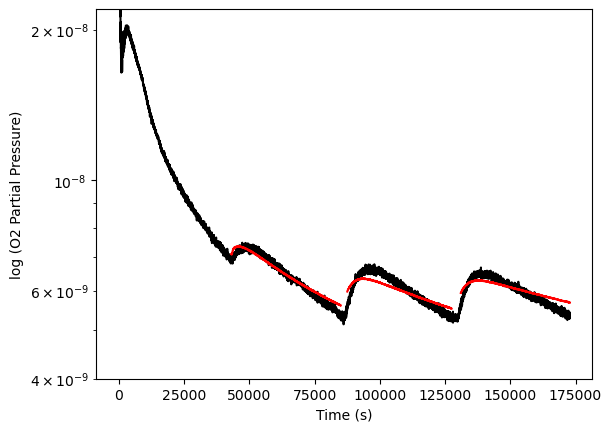

In [11]:
plt.figure()
plt.semilogy(time, p, 'k') # Plot the logarithm (base 10) of the partial pressure of O2 (oxygen) against time. 
for i in range(len(combined_data)):
    plt.plot(combined_data[i][0], np.abs(d.fitfunction_short_temp_offset(tT[i], *res.x)), 'r')
plt.ylabel('log (O2 Partial Pressure)') 
plt.xlabel('Time (s)')


plt.ylim(4e-9, 2.2e-8)


plt.show()


In [12]:
print(res.x)

[1.32237436e-03 4.05208279e+03 1.17663334e-03 9.99990182e-01
 1.61801857e-03]


(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)


(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)
(2, 1380)


(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)


(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)


(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)
(2, 1315)


...

(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)


(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)


(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)


(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)
(2, 1375)


(1000.0, 190000.0)

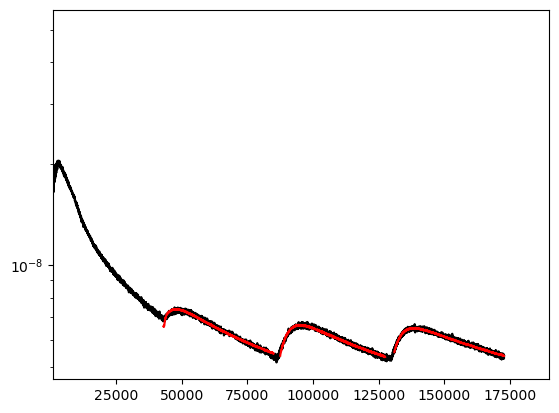

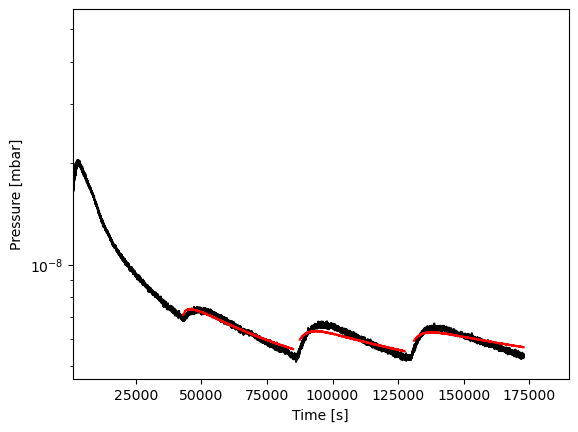

In [13]:
#Plotting Code

time_slices = [[43000, 85000],
               [87500, 127500],
               [131000, 175000]]

#Plot with different fit parameters for each time slice

plt.figure()
plt.semilogy(time, p, 'k')

for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT = np.vstack((time[gpts], temp[gpts]))
    y = p[gpts]
    spars = [1.29648471e-03, 4.99649264e+03, 8.11283810e-04, 1, -3.72000013e-03]
    #spars = [3.48859880e-09, -3.45969798e+01, 3.98032858e-01, 1, 0]
    #Spars that work for curvefit: 3.48859880e-09, -3.45969798e+01, 3.98032858e-01, 1, 0
    #Spars from old teflon data: 3.48859880e-09, 3.45969798e+03, 3.98032858e-01, 1, 0
    #res = minimize(combined_chisq_short, spars, args=(combined_data), method='Nelder-Mead')
    #bp = res.x
    bp, bc = curve_fit(d.fitfunction_short_temp_offset, tT, y, p0=spars, method='lm', maxfev=90000)
    plt.plot(tT[0], d.fitfunction_short_temp_offset(tT,*bp),'r')
    print('bp:', bp)
    #plt.ylim(2e-10, 1e-8)
    plt.xlim(1e3, 19e4)
    #res = minimize(combined_chisq_short, spars, args=(combined_data,))
    #bp = res.x
   

#Plot with the same fit parameters for all time slices
tT = []
y = []
combined_data = []
plt.figure()
plt.semilogy(time, p, 'k')
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT.append((np.vstack((time[gpts], temp[gpts]))))
    y.append(p[gpts])
    combined_data.append([time[gpts], p[gpts]])
spars = [1.29648471e-03, 4.99649264e+03, 8.11283810e-04, 1, -3.72000013e-03]
#spars = [7.08859880e-05, 3.45969798e+03, 1.28032858e+03, 1, 5]
#bp, bc = curve_fit(d.fitfunction_short_temp_offset, np.vstack((time,temp)), p, p0=spars, method='lm', maxfev=90000)
res = minimize(combined_chisq_short, spars, args=(tT, y))
bp = res.x


for j in range(len(time_slices)):
    tvals = combined_data[j][0]
    plt.plot(tvals, d.fitfunction_short_temp_offset(tT[j], *bp), 'r')
   
    

print('bp:', bp)

plt.ylabel('Pressure [mbar]')
plt.xlabel("Time [s]")
#plt.ylim(2e-9, 1e-7)
plt.xlim(1e3, 19e4)



In [30]:
tvec = np.logspace(-6,0,1000)

maxn = 200

fval = np.zeros_like(tvec)
for n in range(maxn):
    fval += np.exp(-(np.pi*(2*n+1))**2*tvec)

plt.figure()
plt.loglog(tvec, fval)

In [31]:
nwalkers, ndim = 100, 5

ffn = lambda p,d,y: -combined_chisq_short(p,d, y)

scaling_factors = np.array([1e-1, 7e+3, 1e-1, 9.9e-1, 3.7e-3])
p0 = [spars + scaling_factors*0.001*np.random.randn(ndim) for i in range(nwalkers)]
 
sampler = mc.EnsembleSampler(nwalkers, ndim, ffn, args=(tT,y))
sampler.run_mcmc(p0, 4000, progress=True)


In [32]:
# Extract the chain of samples
samples = sampler.get_chain()

# Calculate the median of each parameter across all walkers and steps
median_params = np.median(samples, axis=(0, 1))

# Print the median parameters
print("Median parameters:", median_params)
print('P0:', p0)

In [33]:
fig, axes = plt.subplots(5, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["a", "b", "c", "e","f"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [34]:
import corner

flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)
print(flat_samples.shape)

fig = corner.corner(flat_samples, labels=labels)

In [35]:
plt.figure()
plt.semilogy(time, p, 'k')
tT_final = []
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT_final.append((np.vstack((time[gpts],temp[gpts]))))
inds = np.random.randint(len(flat_samples), size=10)
for ind in inds:
    sample = flat_samples[ind]
    for j in range(len(time_slices)):
        tvals = combined_data[j][0]
        plt.plot(tvals, d.fitfunction_short_temp_offset(tT_final[j], sample[0], sample[1], sample[2], sample[3], sample[4]), 'r', alpha=0.5)

plt.ylim(4e-9, 2.2e-8)
plt.ylabel('Pressure [mbar]')
plt.xlabel("Time [s]")



In [36]:
from IPython.display import display, Math

CI = 10 ## L/s
Area = 0.01 ## m^2
mbar_to_Pa = 100
K = 0.22
p_atm = 1.01e5 #Pa
m_to_cm = 100
L_to_m3 = 1e-3
KbT = 4.14e-21 #J

mcmc_D0 = np.percentile((flat_samples[:, 0]*CI*mbar_to_Pa*L_to_m3/(K*p_atm*Area) * m_to_cm)**2, [16, 50, 84])
mcmc_Ea = np.percentile(flat_samples[:, 1], [16, 50, 84])

print("D0 [cm^2/s]: ", mcmc_D0)
print("Activation energy [K]: ", mcmc_Ea)
print(flat_samples[:,0])
